<a href="https://colab.research.google.com/github/ruilili3-cell/cs5494_tutorial/blob/main/Tutorial2v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** LI Ruilin

**EID:** ruilili3

# CS5489 - Tutorial 2
## Text Document Classification with Naive Bayes

In this tutorial you will classify text documents using Naive Bayes classifers.  We will be working with the dataset called "AGNews", which is a collection of news posts organized into 4 categories: ["World", "Sports", "Business", "Sci/Tech"]

First we need to initialize Python.  Run the below cell.

In [ ]:
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats, special
import json
from collections import Counter
random.seed(100)

Next, put the file "dataAG.json' into the same directory as this ipynb file.
Next, we will extract 4 classes from the dataset.  Run the below cell.

In [ ]:
# all labels
cats = ["World", "Sports", "Business", "Sci/Tech"]

# load the json
with open("/Users/kenny/Desktop/CS5489/Tutorial/T2/dataAG.json") as fd:
    data = json.load(fd)

Now, we check if we got all the data.  The training set should have 2034 documents, and the test set should have 1353 documents.

**Data check:** The supplied `dataAG.json` actually contains 2,000 training and 1,000 test documents. The sizes above are from the original instructions.


In [ ]:
print("training set size:", len(data['train']))
print("testing set size: ",  len(data['test']))
print(Counter(z['label'] for z in data['train']))
print(Counter(z['label'] for z in data['test']))

training set size: 2000
testing set size:  1000
Counter({2: 512, 0: 511, 1: 493, 3: 484})
Counter({0: 262, 1: 261, 2: 249, 3: 228})


Now have a look at the documents.

In [ ]:
for i in range(5):
    d = data['train'][i]
    print(f"--- document {i} (class={d['label']}/{cats[d['label']]}) ---")
    print(d['text'])

--- document 0 (class=0/World) ---
Three UK soldiers killed in central Iraq Three British troops have been killed and others injured in an attack in central Iraq, British Armed Forces Minister Adam Ingram confirmed on Thursday.
--- document 1 (class=3/Sci/Tech) ---
European Spacecraft to Research  #39;Moon Colonies #39; A tiny craft powered by Star Trek technology was standing today at the gateway to the moon - and a landmark date in the history of European space exploration.
--- document 2 (class=1/Sports) ---
Wicked good outcome So where should the Boston Red Sox start their World Series parade? That #39;s the question. At Bill Buckner #39;s house? How about from in front of Aaron Boone #39;s plasma screen?
--- document 3 (class=3/Sci/Tech) ---
Yahoo! loses US appeal over French ruling on Nazi auctions Yahoo! has lost an appeal against a US district courts ruling which said that the company does not have to obey a French courts decision requiring it to block French citizens from acce

### Build document vectors
Create the vocabulary from the training data.  Then build the document vectors for the training and testing sets.  You can decide how many words you want in the vocabulary.

In [ ]:
# pull out the document data and labels
traindata = [x['text'] for x in data['train']]
trainY = [x['label'] for x in data['train']]

testdata = [x['text'] for x in data['test']]
testY  = [x['label'] for x in data['test']]

In [ ]:
cntvect = feature_extraction.text.CountVectorizer(stop_words='english', max_features=1000)
cntvect.fit(traindata)

trainX = cntvect.transform(traindata)
testX  = cntvect.transform(testdata)

print("vocabulary size:", len(cntvect.vocabulary_))
print("trainX shape:", trainX.shape)
print("testX shape: ", testX.shape)

vocabulary size: 1000
trainX shape: (2000, 1000)
testX shape:  (1000, 1000)


###  Bernoulli Naive Bayes
Learn a Bernoulli Naive Bayes model from the training set.  What is the prediction accuracy on the test set?  Try different parameters (alpha, max_features, etc) to get the best performance.

**Evaluation note:** Following the tutorial's requested test-accuracy experiments,
these loops compare parameters on the supplied test set. Their maximum scores
are exploratory results, not unbiased estimates on an untouched test set.
For a formal evaluation, select parameters using a training-only validation split
or cross-validation (fitting both the vocabulary and IDF inside each split),
then evaluate once on the test set. `max_features` is an upper bound; several
large settings can produce exactly the same actual vocabulary.


In [ ]:
# Use positive smoothing: alpha=0 can produce log(0) and undefined scores.
print("  alpha  max_features  test accuracy")
b_best_acc = -1.0
b_best_alpha = 0.0
b_best_mf = 0
for mf in [100, 500, 1000, 2000, 5000, 10000,20000, 50000, 100000,200000]:
    cv = feature_extraction.text.CountVectorizer(stop_words='english', max_features=mf)
    Xtr = cv.fit_transform(traindata)
    Xte = cv.transform(testdata)
    for a in [0.01,0.79,0.795,0.8,0.81,0.825,0.85, 0.9, 1.0]:
        bm = naive_bayes.BernoulliNB(alpha=a)
        bm.fit(Xtr, trainY)
        acc = metrics.accuracy_score(testY, bm.predict(Xte))
        print("{:7.3f}  {:8d}  {:.4f}".format(a, mf, acc))
        if acc > b_best_acc:
            b_best_acc, b_best_alpha, b_best_mf = acc, a, mf

cntvect = feature_extraction.text.CountVectorizer(stop_words='english', max_features=b_best_mf)
trainX = cntvect.fit_transform(traindata)
testX  = cntvect.transform(testdata)
bmodel = naive_bayes.BernoulliNB(alpha=b_best_alpha)
bmodel.fit(trainX, trainY)

print("best: alpha={}, max_features={}, test accuracy={:.4f}".format(b_best_alpha, b_best_mf, b_best_acc))
# Keep this vocabulary with its model, even after later cells run.
b_cntvect = cntvect
print("actual vocabulary size:", len(b_cntvect.vocabulary_))


  alpha  max_features  test accuracy
  0.010       100  0.6830
  0.790       100  0.6850
  0.795       100  0.6850
  0.800       100  0.6850
  0.810       100  0.6850
  0.825       100  0.6850
  0.850       100  0.6840
  0.900       100  0.6840
  1.000       100  0.6840
  0.010       500  0.7860
  0.790       500  0.7800
  0.795       500  0.7800
  0.800       500  0.7800
  0.810       500  0.7780
  0.825       500  0.7780
  0.850       500  0.7780
  0.900       500  0.7800
  1.000       500  0.7800
  0.010      1000  0.8160
  0.790      1000  0.8230
  0.795      1000  0.8230
  0.800      1000  0.8230
  0.810      1000  0.8230
  0.825      1000  0.8230
  0.850      1000  0.8220
  0.900      1000  0.8220
  1.000      1000  0.8210
  0.010      2000  0.8350
  0.790      2000  0.8430
  0.795      2000  0.8430
  0.800      2000  0.8430
  0.810      2000  0.8430
  0.825      2000  0.8430
  0.850      2000  0.8440
  0.900      2000  0.8440
  1.000      2000  0.8420
  0.010      5000  0.8450
 

What are the most important (frequent) words for each category?  Run the below code.

Note: `model.feature_log_prob_[i]` will index the word log-probabilities for the i-th class

These are the most frequent words under each class model. As Lecture 2b explains, the most discriminative words instead require comparing probabilities across classes.


In [ ]:
# get the word names
fnames = asarray(b_cntvect.get_feature_names_out())
for i,c in enumerate(cats):
    tmp = argsort(bmodel.feature_log_prob_[i])[-10:]
    print("class", c)
    for t in tmp:
        print("    {:9s} ({:.5f})".format(fnames[t], bmodel.feature_log_prob_[i][t]))

class World
    people    (-2.43747)
    wednesday (-2.41539)
    ap        (-2.35193)
    minister  (-2.21786)
    killed    (-2.21786)
    president (-2.21786)
    iraq      (-2.11572)
    reuters   (-1.88544)
    39        (-1.64646)
    said      (-1.38907)
class Sports
    saturday  (-2.40172)
    ap        (-2.40172)
    year      (-2.37964)
    team      (-2.33689)
    win       (-2.31618)
    night     (-2.25651)
    season    (-2.25651)
    game      (-2.23739)
    new       (-2.21862)
    39        (-1.05163)
class Business
    percent   (-2.18459)
    corp      (-2.15057)
    york      (-2.08581)
    oil       (-2.07025)
    prices    (-2.02499)
    company   (-1.83725)
    new       (-1.60872)
    reuters   (-1.55199)
    said      (-1.39102)
    39        (-1.26612)
class Sci/Tech
    corp      (-2.55330)
    computer  (-2.55330)
    reuters   (-2.55330)
    internet  (-2.45269)
    company   (-2.18184)
    said      (-2.14598)
    microsoft (-2.09451)
    software  (-2.04

### Multinomial Naive Bayes model
Now learn a multinomial Naive Bayes model using the TF-IDF representation for the documents.  Again try different parameter values to improve the test accuracy.

In [ ]:
# Use positive smoothing: alpha=0 can produce log(0) and undefined scores.
print("  alpha  max_features  test accuracy")
m_best_acc = -1.0
m_best_alpha = 0.0
m_best_mf = 0
for mf in [100, 500, 1000, 2000, 3000,4000,5000,6000,7000, 10000,20000, 50000, 100000,200000]:
    cv = feature_extraction.text.CountVectorizer(stop_words='english', max_features=mf)
    Xtr = cv.fit_transform(traindata)
    Xte = cv.transform(testdata)
    tf = feature_extraction.text.TfidfTransformer(use_idf=True, norm='l1')
    Xtr_tf = tf.fit_transform(Xtr)
    Xte_tf = tf.transform(Xte)
    for a in [0.01,0.09,0.1,0.11,0.2,0.3,0.4,0.5]:
        mm = naive_bayes.MultinomialNB(alpha=a)
        mm.fit(Xtr_tf, trainY)
        acc = metrics.accuracy_score(testY, mm.predict(Xte_tf))
        print("{:7.3f}  {:8d}  {:.4f}".format(a, mf, acc))
        if acc > m_best_acc:
            m_best_acc, m_best_alpha, m_best_mf = acc, a, mf

cntvect = feature_extraction.text.CountVectorizer(stop_words='english', max_features=m_best_mf)
trainX = cntvect.fit_transform(traindata)
testX  = cntvect.transform(testdata)
tf_trans = feature_extraction.text.TfidfTransformer(use_idf=True, norm='l1')
trainXtf = tf_trans.fit_transform(trainX)
testXtf  = tf_trans.transform(testX)
mmodel_tf = naive_bayes.MultinomialNB(alpha=m_best_alpha)
mmodel_tf.fit(trainXtf, trainY)

print("best: alpha={}, max_features={}, test accuracy={:.4f}".format(m_best_alpha, m_best_mf, m_best_acc))
# Keep this vocabulary with its model, even after later cells run.
m_cntvect = cntvect
print("actual vocabulary size:", len(m_cntvect.vocabulary_))


  alpha  max_features  test accuracy
  0.010       100  0.6850
  0.090       100  0.6870
  0.100       100  0.6870
  0.110       100  0.6870
  0.200       100  0.6860
  0.300       100  0.6870
  0.400       100  0.6860
  0.500       100  0.6870
  0.010       500  0.7980
  0.090       500  0.7990
  0.100       500  0.7990
  0.110       500  0.7980
  0.200       500  0.7980
  0.300       500  0.7980
  0.400       500  0.7980
  0.500       500  0.7980
  0.010      1000  0.8130
  0.090      1000  0.8160
  0.100      1000  0.8170
  0.110      1000  0.8170
  0.200      1000  0.8170
  0.300      1000  0.8210
  0.400      1000  0.8200
  0.500      1000  0.8200
  0.010      2000  0.8330
  0.090      2000  0.8320
  0.100      2000  0.8300
  0.110      2000  0.8310
  0.200      2000  0.8290
  0.300      2000  0.8260
  0.400      2000  0.8280
  0.500      2000  0.8250
  0.010      3000  0.8450
  0.090      3000  0.8480
  0.100      3000  0.8480
  0.110      3000  0.8480
  0.200      3000  0.8430
 

What are the most important features for Multinomial model? Run the below code.

In [ ]:
# get the word names
fnames = asarray(m_cntvect.get_feature_names_out())
for i,c in enumerate(cats):
    tmp = argsort(mmodel_tf.feature_log_prob_[i])[-10:]
    print("class", c)
    for t in tmp:
        print("    {:9s} ({:.5f})".format(fnames[t], mmodel_tf.feature_log_prob_[i][t]))

class World
    president (-5.91834)
    iraqi     (-5.86224)
    baghdad   (-5.86132)
    minister  (-5.82779)
    reuters   (-5.73852)
    killed    (-5.70314)
    ap        (-5.62938)
    39        (-5.60100)
    said      (-5.57724)
    iraq      (-5.30409)
class Sports
    league    (-6.06450)
    cup       (-6.06324)
    lead      (-6.03722)
    win       (-5.97448)
    team      (-5.97192)
    night     (-5.96248)
    game      (-5.81797)
    season    (-5.76313)
    ap        (-5.65007)
    39        (-4.90790)
class Business
    shares    (-5.88158)
    percent   (-5.81152)
    stocks    (-5.80196)
    company   (-5.68193)
    new       (-5.63675)
    said      (-5.58265)
    prices    (-5.46266)
    reuters   (-5.33751)
    oil       (-5.32021)
    39        (-5.25542)
class Sci/Tech
    security  (-6.13383)
    internet  (-6.04511)
    music     (-6.02757)
    computer  (-5.99431)
    company   (-5.96263)
    quot      (-5.88825)
    39        (-5.75114)
    software  (-5.49

Finally, look at a few of the misclassified documents.

In [ ]:
predY = mmodel_tf.predict(testXtf)

mis = where(predY != array(testY))[0]
print("number of misclassified documents:", len(mis), "/", len(testY))

for i in mis[:100]:
    print("---- true={}/{}  pred={}/{}".format(testY[i], cats[testY[i]], predY[i], cats[predY[i]]))
    print(testdata[i])
    print()

number of misclassified documents: 142 / 1000
---- true=2/Business  pred=0/World
Hurricane loss 'less than feared' Hurricane Frances could cause \$3-6bn in insured losses in the US, less than experts first predicted.

---- true=0/World  pred=2/Business
Consumer Confidence Dips in September NEW YORK - Job worries helped push consumer confidence down in September for the second consecutive month, a New York-based private research group said Tuesday.    The Consumer Confidence Index fell 1.9 points to 96.8 from a revised reading of 98.7 in August, according to The Conference Board...

---- true=2/Business  pred=0/World
Senate panel opposes overtime rules  A Senate committee voted yesterday to scuttle new rules that critics say would deny overtime pay to millions of workers, as Democrats won the latest round in their election-year bout with President Bush over the issue.

---- true=3/Sci/Tech  pred=1/Sports
Travel Column: Australia Through Aboriginal Eyes This week's TravelWatch column pro

Can you get any intuition or reason why they were misclassified?

Reasons:

1. **Overlapping topics.** "Consumer Confidence Dips in September" is labelled World but predicted Business; "Senate panel opposes overtime rules" is labelled Business but predicted World. Economic and political news can share vocabulary, so the boundary between the categories is ambiguous.
2. **Short documents provide little evidence.** "Hurricane loss 'less than feared'" is labelled Business but predicted World. The text mixes a natural disaster with insured losses, and a few words can dominate the decision.
3. **Ignores relationships and context.** "Travel Column: Australia Through Aboriginal Eyes" is labelled Sci/Tech but predicted Sports. Words such as "Tours" can also occur in sports coverage, which is a possible explanation; confirming the exact cause would require examining the words' contributions to the competing class scores.
4. **The supplied excerpt may omit the main topic.** "Glory Comes Amid Empty Seats and Closed Shutters" is labelled Sports but predicted Sci/Tech. The excerpt describes shutters, heat and pollution without clear sports terms.



### Effect of smoothing
The smoothing (regularization) parameter has effects on the performance.  Using the Multinomial TF-IDF models, make a plot of accuracy versus different values of alpha. For each alpha, you need to train a new model. Which alpha value yields the best result?

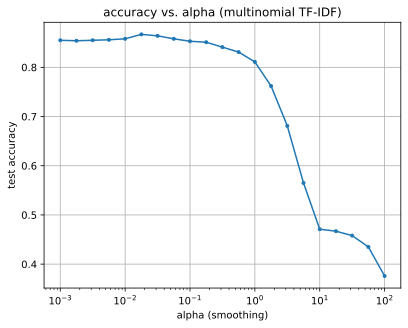

best alpha = 0.017783, accuracy = 0.8670


In [ ]:
alphas = logspace(-3, 2, 21)
accs = []
for a in alphas:
    m = naive_bayes.MultinomialNB(alpha=a)
    m.fit(trainXtf, trainY)
    accs.append(metrics.accuracy_score(testY, m.predict(testXtf)))

accs = array(accs)

plt.figure()
plt.semilogx(alphas, accs, '.-')
plt.xlabel('alpha (smoothing)')
plt.ylabel('test accuracy')
plt.title('accuracy vs. alpha (multinomial TF-IDF)')
plt.grid(True)
plt.show()

ibest = argmax(accs)
smoothing_best_alpha = alphas[ibest]
print("best alpha = {:.6f}, accuracy = {:.4f}".format(smoothing_best_alpha, accs[ibest]))

### Effect of vocabulary size
The vocabulary size also affects the accuracy.  Make another plot of accuracy versus vocabulary size.  Which vocabulary size yields the best result?

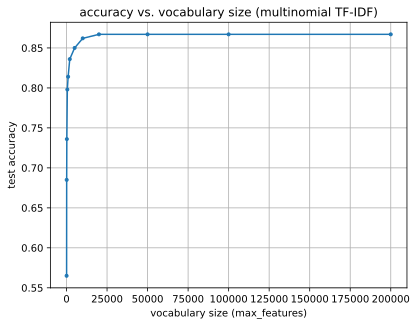

best vocabulary size = 20000, accuracy = 0.8670


In [ ]:
# fix the smoothing parameter (best from the previous cell) and vary the vocabulary size
vocabsizes = [50, 100, 200, 500, 1000, 2000, 5000, 10000,20000, 50000, 100000,200000]
accs = []
for vs in vocabsizes:
    cv = feature_extraction.text.CountVectorizer(stop_words='english', max_features=vs)
    Xtr = cv.fit_transform(traindata)
    Xte = cv.transform(testdata)
    tf = feature_extraction.text.TfidfTransformer(use_idf=True, norm='l1')
    m = naive_bayes.MultinomialNB(alpha=smoothing_best_alpha)
    m.fit(tf.fit_transform(Xtr), trainY)
    accs.append(metrics.accuracy_score(testY, m.predict(tf.transform(Xte))))

accs = array(accs)

# plot accuracy vs. vocabulary size
plt.figure()
plt.plot(vocabsizes, accs, '.-')
plt.xlabel('vocabulary size (max_features)')
plt.ylabel('test accuracy')
plt.title('accuracy vs. vocabulary size (multinomial TF-IDF)')
plt.grid(True)
plt.show()

ibest = argmax(accs)
print("best vocabulary size = {}, accuracy = {:.4f}".format(vocabsizes[ibest], accs[ibest]))

## Poisson Naive Bayes

Now we will implement a Naive Bayes classifier using a Poisson distribution to model the count of each word appearing in the document.  Recall that the Poisson distribution is:
$$ \mathrm{Poisson}(x,\mu) = \frac{1}{x!}e^{-\mu} \mu^x$$
where $x \in \{0,1,2,\cdots\}$ is a counting number, and $\mu$ is the Poisson mean (arrival rate).

Here is some code showing how to compute the Poisson distribution using scipy.

[[ -1.          -2.          -3.5       ]
 [ -1.          -1.30685282  -2.24723703]
 [ -1.69314718  -1.30685282  -1.68762124]
 [ -2.79175947  -1.71231793  -1.53347056]
 [ -4.17805383  -2.40546511  -1.66700196]
 [ -5.78749174  -3.32175584  -2.0236769 ]
 [ -7.57925121  -4.42036813  -2.5626734 ]
 [ -9.52516136  -5.6731311   -3.25582058]
 [-11.6046029   -7.05942546  -4.08249915]
 [-13.80182748  -8.56350286  -5.02696076]
 [-16.10441257 -10.17294077  -6.07678289]
 [-18.50230785 -11.87768886  -7.22191519]
 [-20.9872145  -13.66944833  -8.45405887]
 [-23.55216385 -15.54125051  -9.76624526]
 [-26.19122118 -17.48716065 -11.15253962]
 [-28.89927138 -19.50206368 -12.60782686]
 [-31.67186011 -21.58150522 -14.12765261]
 [-34.50507345 -23.72157138 -15.70810299]
 [-37.39544521 -25.91879596 -17.34571178]
 [-40.33988419 -28.17008776 -19.03738779]]


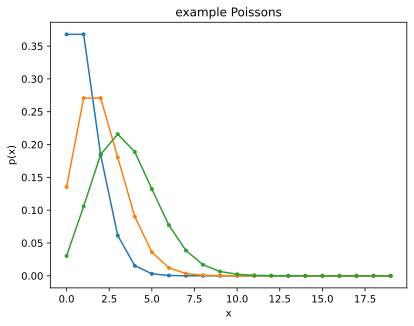

In [ ]:
# Poisson distribution
from scipy.stats import poisson

# compute log Poisson(x, lambda)
px = poisson.logpmf(arange(0,20).reshape((20,1)), mu=[[1., 2., 3.5]])

# NOTE: the function respects broadcasting
# x is a column vector, and mu is a row vector
# in the output px, each column is the log Poisson values for one mu
print(px)

# make a plot
plt.title('example Poissons')
plt.plot(arange(0,20), exp(px), '.-');
plt.xlabel('x')
plt.ylabel('p(x)')
plt.show()

Now let's see how to use the Poisson to create a Naive Bayes model. Let $x_i$ be the number of times the i-th word appears in the document. Then we model $x_i$ as a Poisson distribution for each class $c$,
  $$p(x_i|y=c) = \mathrm{Poisson}(x_i, \mu_{i,c})$$
where $\mu_{i, c}$ is the Poisson parameter for the i-th word in the c-th class.  Given the data $\{x_i^{(1)}, \cdots x_i^{(N)}\}$, corresponding the counts of the i-th word in the documents in the c-th class, $\mu_{i,c}$ is estimated as the mean of the data: $\mu_{i,c} = \frac{1}{N} \sum_{n=1}^N x_i^{(n)}$.

Finally, given the document $\mathbf{x} = [x_1,\cdots,x_D]$, the document class-conditional likelihood is:
  $$ p(\mathbf{x}|y=c) = \prod_{i=1}^D p(x_i|y=c) = \prod_{i=1}^D \mathrm{Poisson}(x_i, \mu_{i,c})$$
or CCD log-likelihood is
  $$ \log p(\mathbf{x}|y=c) = \sum_{i=1}^D \log \mathrm{Poisson}(x_i, \mu_{i,c})$$

Write a class for the Poisson Naive Bayes model.  Starting with the `GaussBayes` class from lecture as the template, you only need to change the estimation of the parameters $\mu_{i,c}$ and the computation of the log CCD.

In [ ]:
# Poisson distribution
from scipy.stats import poisson
from scipy.special import logsumexp

class PoissonNB:
    # constructor:
    #   set regularizer alpha
    def __init__(self, alpha):
        self.alpha = alpha

    # Fit the model: assumes classes are [0,1,2,...K-1]
    # K is the number of classes (max(y) + 1)
    def fit(self, X, y):
        y = array(y)
        K = max(y)+1
        self.K = K
        self.mu = []
        for c in range(K):
            Xc = X[y==c]
            counts = asarray(Xc.sum(axis=0)).ravel()
            self.mu.append( (counts + self.alpha) / (Xc.shape[0] + self.alpha) )
        tmp = []
        for c in range(K):
            tmp.append( count_nonzero(y==c) )
        self.pi = array(tmp) / len(y)

    # compute the log CCD for class c, log p(x|y=c)
    def compute_logccd(self, X, c):
        if hasattr(X, 'toarray'):
            X = X.toarray()
        lx = poisson.logpmf(X, mu=self.mu[c])
        return lx.sum(axis=1)

    # compute the joint log-likelihood: log p(x,y)
    def compute_logjoint(self, X):
        # compute log joint likelihood: log p(x|y) + log p(y)
        jl = []
        for c in range(self.K):
            jl.append( self.compute_logccd(X, c) + log(self.pi[c]) )

        p = stack( jl, axis=-1 )
        return p

    # compute the posterior log-probability of each class given X
    def predict_logproba(self, X):
        lp = self.compute_logjoint(X)
        lpx = logsumexp(lp, axis=1)
        return lp - lpx[:,newaxis]

    # compute the posterior probability of each class given X
    def predict_proba(self, X):
        return exp( self.predict_logproba(X) )

    # compute the most likely class given X
    def predict(self, X):
        lp = self.compute_logjoint(X)
        c = argmax(lp, axis=1)
        return c

Now test your Poisson NB model on the dataset.

In [ ]:
p_best_acc = -1.0
p_best_alpha = None
p_best_mf = None
for mf in [1000, 5000,10000, 20000, 50000, 100000, 200000]:
    cv = feature_extraction.text.CountVectorizer(stop_words='english', max_features=mf)
    Xtr = cv.fit_transform(traindata)
    Xte = cv.transform(testdata)
    for a in [0.47,0.48,0.49,0.50,0.51,0.52, 0.53, 0.54, 0.55 ,1.00, 2.00, 5.00]:
        pm = PoissonNB(alpha=a)
        pm.fit(Xtr, trainY)
        predYp = pm.predict(Xte)
        acc = metrics.accuracy_score(testY, predYp)
        print("max_features={:4d}, alpha={:.2f}: test accuracy = {:.4f}".format(mf, a, acc))
        if acc > p_best_acc:
            p_best_acc = acc
            p_best_mf = mf
            p_best_alpha = a

print("\nBest result:")
print("max_features =", p_best_mf)
print("alpha        =", p_best_alpha)
print("accuracy     = {:.4f}".format(p_best_acc))
# Refit and retain the actual best Poisson model (pm above is the LAST trial).
p_cntvect = feature_extraction.text.CountVectorizer(
    stop_words='english', max_features=p_best_mf)
trainXp = p_cntvect.fit_transform(traindata)
testXp = p_cntvect.transform(testdata)
pmodel = PoissonNB(alpha=p_best_alpha)
pmodel.fit(trainXp, trainY)
predYp = pmodel.predict(testXp)
assert isclose(metrics.accuracy_score(testY, predYp), p_best_acc)
print("actual vocabulary size:", len(p_cntvect.vocabulary_))


max_features=1000, alpha=0.47: test accuracy = 0.8170
max_features=1000, alpha=0.48: test accuracy = 0.8170
max_features=1000, alpha=0.49: test accuracy = 0.8170
max_features=1000, alpha=0.50: test accuracy = 0.8170
max_features=1000, alpha=0.51: test accuracy = 0.8170
max_features=1000, alpha=0.52: test accuracy = 0.8170
max_features=1000, alpha=0.53: test accuracy = 0.8170
max_features=1000, alpha=0.54: test accuracy = 0.8160
max_features=1000, alpha=0.55: test accuracy = 0.8160
max_features=1000, alpha=1.00: test accuracy = 0.8120
max_features=1000, alpha=2.00: test accuracy = 0.8100
max_features=1000, alpha=5.00: test accuracy = 0.7850
max_features=5000, alpha=0.47: test accuracy = 0.8530
max_features=5000, alpha=0.48: test accuracy = 0.8530
max_features=5000, alpha=0.49: test accuracy = 0.8540
max_features=5000, alpha=0.50: test accuracy = 0.8540
max_features=5000, alpha=0.51: test accuracy = 0.8540
max_features=5000, alpha=0.52: test accuracy = 0.8540
max_features=5000, alpha=0.5

How does the Poisson NB model compare with the other models that you tested? Is this a good model for documents?

The results below come from the complete execution of this notebook. Each row uses the indicated model's own search, so the vocabulary settings are not all identical.

| Model / experiment | Best alpha | max_features (upper bound) | Actual vocabulary | Test accuracy |
|---|---:|---:|---:|---:|
| Bernoulli NB search | 0.79 | 200000 | 11171 | 0.867 |
| Multinomial NB + L1 TF-IDF initial search | 0.01 | 200000 | 11171 | 0.858 |
| Multinomial NB + L1 TF-IDF smoothing sweep | 0.0177828 | 200000 | 11171 | 0.867 |
| Poisson NB search | 0.50 | 200000 | 11171 | 0.865 |

The Poisson Naive Bayes model achieved a test accuracy of 0.865, which is competitive with the other models. It performed slightly worse than the Bernoulli model and the Multinomial TF-IDF model after smoothing, both of which achieved 0.867, but it performed better than the initial Multinomial TF-IDF experiment, which achieved 0.858.

Poisson Naive Bayes is reasonable for document classification because word frequencies are non-negative integer counts, which match the support of the Poisson distribution. However, it assumes that word counts are conditionally independent and that their variance equals their mean. Real documents may contain bursty words and different lengths, so these assumptions can be restrictive. Therefore, Poisson Naive Bayes is a useful and competitive model for this dataset, but it is not necessarily the best general model for all document-classification tasks. The reported results are exploratory because the parameters were selected using the same test set.
